In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Plot settings
plt.style.use('default')

In [227]:
# Load dataset
df = pd.read_csv('reviews.csv')

print(f"Original Dataset Shape: {df.shape}")
print(f"Memory Usage: {round(df.memory_usage(deep=True).sum()/1024**2, 2)} MB")

print("\nColumn Names:")
print(df.columns.tolist())

display(df.head())

Original Dataset Shape: (568454, 10)
Memory Usage: 424.08 MB

Column Names:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


Phase 1

In [228]:
# Keep only necessary columns
columns_to_keep = ['UserId', 'ProductId', 'Score', 'Summary', 'Text']
df = df[columns_to_keep]

# Drop rows with missing essential values
df = df.dropna(subset=['UserId', 'ProductId', 'Score'])

# Remove duplicate reviews
df = df.drop_duplicates()

# Optimize datatype
df['Score'] = df['Score'].astype(np.float32)

print(f"Dataset Shape after cleaning: {df.shape}")
display(df.head())

Dataset Shape after cleaning: (567562, 5)


,UserId,ProductId,Score,Summary,Text
0,A3SGXH7AUHU8GW,B001E4KFG0,5.0,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,A1D87F6ZCVE5NK,B00813GRG4,1.0,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,ABXLMWJIXXAIN,B000LQOCH0,4.0,"""Delight"" says it all",This is a confection that has been around a fe...
3,A395BORC6FGVXV,B000UA0QIQ,2.0,Cough Medicine,If you are looking for the secret ingredient i...
4,A1UQRSCLF8GW1T,B006K2ZZ7K,5.0,Great taffy,Great taffy at a great price. There was a wid...


In [229]:
# from sklearn.model_selection import train_test_split

# train_list = []
# test_list = []

# for user_id, group in df_filtered.groupby('UserId'):

#     if len(group) < 2:
#         train_list.append(group)
#         continue

#     train, test = train_test_split(
#         group,
#         test_size=0.2,
#         random_state=42
#     )

#     train_list.append(train)
#     test_list.append(test)

# train_df = pd.concat(train_list)
# test_df = pd.concat(test_list)

# print("Train-Test Split Complete!")
# print(f"Train Shape: {train_df.shape}")
# print(f"Test Shape: {test_df.shape}")
# print(f"Train Users: {train_df['UserId'].nunique()}")
# print(f"Test Users: {test_df['UserId'].nunique()}")

In [230]:
# Define thresholds
min_user_reviews = 5
min_product_reviews = 15

# Iterative filtering for better sparsity reduction
while True:
    initial_shape = df.shape[0]

    # Filter products
    product_counts = df['ProductId'].value_counts()
    active_products = product_counts[product_counts >= min_product_reviews].index
    df = df[df['ProductId'].isin(active_products)]

    # Filter users
    user_counts = df['UserId'].value_counts()
    active_users = user_counts[user_counts >= min_user_reviews].index
    df = df[df['UserId'].isin(active_users)]

    final_shape = df.shape[0]

    if initial_shape == final_shape:
        break

df_filtered = df.copy()

print(f"Dataset Shape after sparsity filtering: {df_filtered.shape}")
print(f"Total Unique Users left: {df_filtered['UserId'].nunique()}")
print(f"Total Unique Products left: {df_filtered['ProductId'].nunique()}")

Dataset Shape after sparsity filtering: (142175, 5)
Total Unique Users left: 14712
Total Unique Products left: 1690


In [231]:
from sklearn.model_selection import train_test_split

train_list = []
test_list = []

for user_id, group in df_filtered.groupby('UserId'):

    if len(group) < 2:
        train_list.append(group)
        continue

    train, test = train_test_split(
        group,
        test_size=0.2,
        random_state=42
    )

    train_list.append(train)
    test_list.append(test)

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

print("Train-Test Split Complete!")
print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")
print(f"Train Users: {train_df['UserId'].nunique()}")
print(f"Test Users: {test_df['UserId'].nunique()}")

Train-Test Split Complete!
Train Shape: (107876, 5)
Test Shape: (34299, 5)
Train Users: 14712
Test Users: 14712


In [232]:
# import string

# # Fill any remaining NaNs in text columns with empty strings
# df_filtered['Summary'] = df_filtered['Summary'].fillna('')
# df_filtered['Text'] = df_filtered['Text'].fillna('')

# # Function to clean text
# def clean_text(text):
#     text = text.lower() # Lowercase
#     text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
#     return text

# # Apply to the Summary column
# df_filtered['Clean_Summary'] = df_filtered['Summary'].apply(clean_text)

# print("Text preprocessing complete; Sample:")
# display(df_filtered[['Summary', 'Clean_Summary']].head(3))

Phase 2

C:\Users\aayus\AppData\Local\Temp\ipykernel_8928\3139204795.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_filtered, x='Score', palette='viridis')


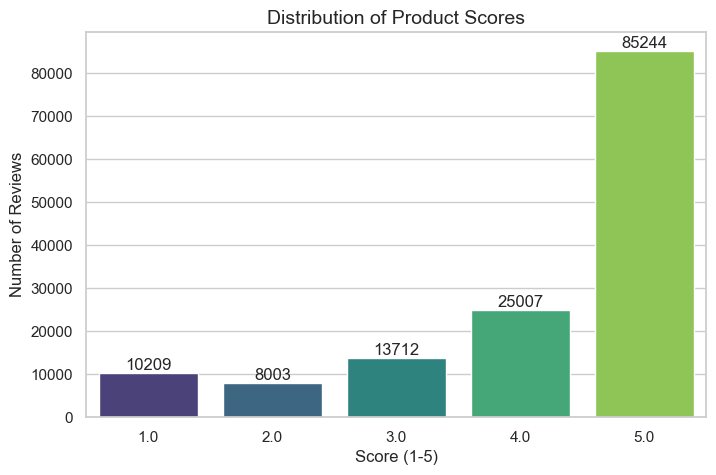

Average Rating: 4.18


In [233]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_filtered, x='Score', palette='viridis')

plt.title('Distribution of Product Scores', fontsize=14)
plt.xlabel('Score (1-5)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

print(f"Average Rating: {df_filtered['Score'].mean():.2f}")

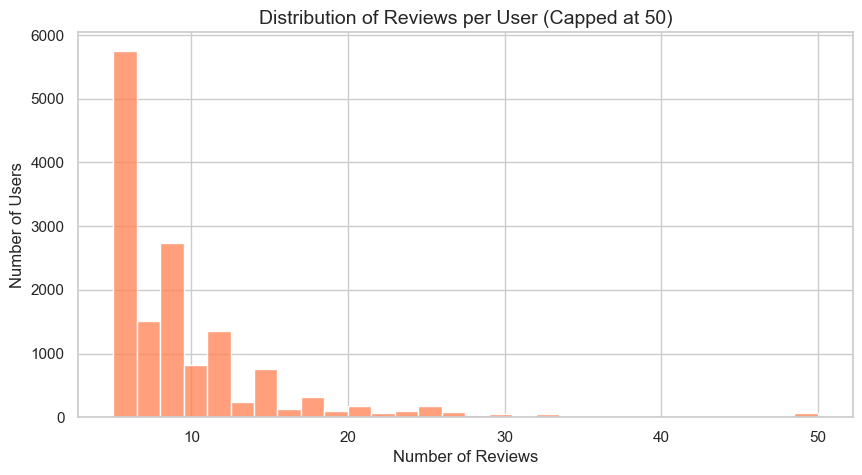

Average Reviews/User: 9.66
Median Reviews/User: 8.00
Max Reviews by a User: 139


In [234]:
plt.figure(figsize=(10, 5))

user_review_counts = df_filtered['UserId'].value_counts()

sns.histplot(
    user_review_counts.clip(upper=50),
    bins=30,
    kde=False,
    color='coral'
)

plt.title('Distribution of Reviews per User (Capped at 50)', fontsize=14)
plt.xlabel('Number of Reviews', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.show()

print(f"Average Reviews/User: {user_review_counts.mean():.2f}")
print(f"Median Reviews/User: {user_review_counts.median():.2f}")
print(f"Max Reviews by a User: {user_review_counts.max()}")

Phase 3

In [235]:
from scipy.sparse.linalg import svds

# 1. Create User-Item Matrix using TRAIN data only
user_item_matrix = train_df.pivot_table(
    index='UserId',
    columns='ProductId',
    values='Score',
    aggfunc='mean'
)

print(f"User-Item Matrix Shape: {user_item_matrix.shape}")

# 2. Compute user mean ratings (ignoring NaN)
user_ratings_mean = user_item_matrix.mean(axis=1)

# 3. Normalize ratings
matrix_norm = user_item_matrix.sub(user_ratings_mean, axis=0)

# 4. Fill missing values after normalization
matrix_norm_filled = matrix_norm.fillna(0)

# Convert to numpy
matrix_values = matrix_norm_filled.values

# 5. Apply SVD
# k = min(50, min(matrix_values.shape)-1)
# --- SET YOUR K VALUE HERE ---
chosen_k = 150  # Try changing this to 100, 150, etc.

# Safety check: k must be strictly less than the smallest dimension of your matrix
max_possible_k = min(matrix_values.shape) - 1
k = min(chosen_k, max_possible_k)

print(f"Running SVD with k={k}...")

U, sigma, Vt = svds(matrix_values, k=k)

sigma = np.diag(sigma)

print("Matrix Factorization complete!")

User-Item Matrix Shape: (14712, 1686)
Running SVD with k=150...
Matrix Factorization complete!


In [236]:
# Reconstruct predicted ratings matrix
predicted_ratings = np.dot(np.dot(U, sigma), Vt)

# Add user mean ratings back
predicted_ratings = predicted_ratings + user_ratings_mean.values.reshape(-1, 1)

# Keep predictions within valid rating range
predicted_ratings = np.clip(predicted_ratings, 1, 5)

# Convert to DataFrame
preds_df = pd.DataFrame(
    predicted_ratings,
    columns=user_item_matrix.columns,
    index=user_item_matrix.index
)

print("Predictions generated successfully!")
display(preds_df.head())

Predictions generated successfully!


ProductId       7310172001  7310172101  B00004CI84  B00004CXX9  B00004RYGX  B000084DWM  B000084ETV  B000084EZ4  B000084F6F  B00008CQVA  B00008JOL0  B0000CEPED  B0000DJ7RX  B0000DJ7SR  B0000DJ7TL  B0000TSQ6G  B0000TSQ6Q  B00014DXCC  B00014FKPA  B00014H710  B00014JYNO  B0001ES9F8  B0001TPOY2  B00020HHAO  B00020HHE0  B00020HHGS  B00020HHHC  B00020HHK4  B00020HHM2  B00020HHRW  B00024DB5K  B00024DB6Y  B000255OIG  B00028P3CK  B0002ARQYQ  B0002DGJS2  B0002DGRPC  B0002DGRQ6  B0002DGRRA  B0002DGRSY  B0002DGRZC  B0002DJZX8  B0002H3R2E  B0002I0GUY  B0002JFVJE  B0002MLA5K  B0006345PW  B0006I5M2M  B0006M13WG  B0006M13XK  B0006MU87W  B0006MVRPE  B0006MWNP2  B0006NEHLY  B0006UIJVG  B0006VSXBG  B0006VSXBQ  B0006Z7NOK  B00073IVAQ  B00073JVFU  B0007A0AOY  B0007A0AP8  B0007A0APS  B0007A0AQM  B0007A0AQW  B0007R9L4M  B000812K0O  B00099XNZ6  B00099ZGFG  B0009DY554  B0009JJB6G  B0009VO58S  B0009XQWDM  B0009YJ4CW  B000AY9UBQ  B000AYDH88  B000AYFATW  B000AYFCEU  B000AYFCF4  B000AYGXKC  B000BRR8VQ  \
UserId                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
A1004703RC79J9    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000    4.000000   
A100IC7JRCQDUD    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000    5.000000   
A100WO06OQR8BQ    3.027755    3.028955  

In [237]:
def recommend_products(predictions_df, user_id, original_df, num_recommendations=5):
    
    # Check if user exists
    if user_id not in predictions_df.index:
        print("User not found.")
        return None
    
    # 1. Get user's predicted ratings
    sorted_user_predictions = predictions_df.loc[user_id].sort_values(ascending=False)
    
    # 2. Get products already reviewed by user
    user_data = original_df[original_df['UserId'] == user_id]
    user_history = set(user_data['ProductId'])
    
    # 3. Filter products user hasn't interacted with
    recommendations = sorted_user_predictions[
        ~sorted_user_predictions.index.isin(user_history)
    ]
    
    # 4. Top recommendations
    top_recommendations = recommendations.head(num_recommendations)
    
    print(f"Top {num_recommendations} recommendations for User {user_id}:")
    
    for prod_id, score in top_recommendations.items():
        print(f"Product: {prod_id} | Predicted Score: {score:.4f}")
    
    return top_recommendations

Phase 4

In [238]:
print("Train users:", train_df['UserId'].nunique())
print("Test users:", test_df['UserId'].nunique())
print("Prediction users:", len(preds_df.index))
print("Common users:", len(set(test_df['UserId']).intersection(set(preds_df.index))))

Train users: 14712
Test users: 14712
Prediction users: 14712
Common users: 14712


In [239]:
import numpy as np
from sklearn.metrics import ndcg_score

def evaluate_ranking_metrics(predictions_df, train_df, test_df, k=5):
    
    users = list(set(test_df['UserId']).intersection(set(predictions_df.index)))
    
    if len(users) == 0:
        print("No common users between test set and predictions.")
        return
        
    print(f"Total common users available for evaluation: {len(users)}")

    users = np.random.choice(users, size=min(100, len(users)), replace=False)

    precisions = []
    recalls = []
    ndcgs = []
    
    # Counters to see why users are skipped
    users_skipped_no_relevant = 0
    users_skipped_all_seen = 0

    for user in users:
        # Relevant items from TEST set (actual unseen future interactions)
        # Note: We are looking for items they rated 4 or 5.
        test_user_data = test_df[
            (test_df['UserId'] == user) &
            (test_df['Score'] >= 4)
        ]

        actual_relevant_items = set(test_user_data['ProductId'])

        if len(actual_relevant_items) == 0:
            users_skipped_no_relevant += 1
            continue

        # Items already seen in TRAIN set
        train_user_data = train_df[train_df['UserId'] == user]
        seen_items = set(train_user_data['ProductId'])

        # Predicted scores
        preds = predictions_df.loc[user]

        # Exclude seen items
        preds = preds[~preds.index.isin(seen_items)]

        if len(preds) == 0:
            users_skipped_all_seen += 1
            continue

        # Top-K recommendations
        top_k_preds = preds.sort_values(ascending=False).head(k)
        predicted_items = list(top_k_preds.index)
        
        if len(predicted_items) == 0:
            continue

        # Hits
        hits = [1 if item in actual_relevant_items else 0 for item in predicted_items]

        # Precision@K
        precision = sum(hits) / k
        precisions.append(precision)

        # Recall@K
        recall = sum(hits) / len(actual_relevant_items)
        recalls.append(recall)

        # NDCG@K
        true_relevance = np.asarray([
            [1 if item in actual_relevant_items else 0 for item in predicted_items]
        ])

        pred_scores = np.asarray([top_k_preds.values])

        ndcg = ndcg_score(true_relevance, pred_scores)
        ndcgs.append(ndcg)

    # --- Print Diagnostics ---
    print(f"Users skipped because they had no highly rated items (>=4) in test set: {users_skipped_no_relevant}")
    print(f"Users skipped because they had no unseen items left to predict: {users_skipped_all_seen}")
    print(f"Users successfully evaluated: {len(precisions)}")

    if not precisions:
        print("\n[!] No users could be evaluated. Try changing `test_df['Score'] >= 4` to `>= 3` to relax the rules, or increase your dataset size.")
        return

    print(f"\n--- Evaluation Metrics @ K={k} ---")
    print(f"Average Precision@{k}: {np.mean(precisions):.4f}")
    print(f"Average Recall@{k}: {np.mean(recalls):.4f}")
    print(f"Average NDCG@{k}: {np.mean(ndcgs):.4f}")


print("Before function call")
evaluate_ranking_metrics(preds_df, train_df, test_df, k=5)
print("After function call")

Before function call
Total common users available for evaluation: 14712
Users skipped because they had no highly rated items (>=4) in test set: 20
Users skipped because they had no unseen items left to predict: 0
Users successfully evaluated: 80

--- Evaluation Metrics @ K=5 ---
Average Precision@5: 0.0425
Average Recall@5: 0.0877
Average NDCG@5: 0.1156
After function call


In [240]:
# Save the predictions and user history to pickle files for the web app
import pickle

# Save the predictions matrix
preds_df.to_pickle('predictions.pkl')

# Save a simplified version of the user history (just what we need for filtering)
user_history = df_filtered[['UserId', 'ProductId']].drop_duplicates()
user_history.to_pickle('user_history.pkl')

print("Data successfully saved for the web app!")

Data successfully saved for the web app!
